In [8]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install datasets

   ---------------------------------------- 0.0/534.5 kB ? eta -:--:--
   ---------------------------------------- 534.5/534.5 kB 30.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 45.6 MB/s  0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   --------------- ------------------------ 10.7/27.6 MB 54.6 MB/s eta 0:00:01
   ------------------------------ --------- 21.0/27.6 MB 52.1 MB/s eta 0:00:01
   ---------------------------------------- 27.6/27.6 MB 49.9 MB/s  0:00:00

   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------  2/16 [pyarrow]
   ----- ----------------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datasets import load_dataset

ds = load_dataset("PedroSampaio/fruits-360")

In [5]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 67690
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 22688
    })
})

In [3]:
# 데이터셋에서 사용 가능한 클래스 목록 확인
print("Classes available in Fruits-360:")
print(f"Number of classes: {ds['train'].features['label'].num_classes}")
print(f"Class names: {ds['train'].features['label'].names}")
print(f"\nTotal samples: {len(ds['train'])} (train) + {len(ds['test'])} (test)")

Classes available in Fruits-360:
Number of classes: 113
Class names: ['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden', 'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red', 'Apple Red Delicious', 'Apple Red Yellow', 'Apricot', 'Avocado', 'Avocado ripe', 'Banana', 'Banana Lady Finger', 'Banana Red', 'Beetroot', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Carambula', 'Cauliflower', 'Cherry', 'Cherry Rainier', 'Cherry Wax Black', 'Cherry Wax Red', 'Cherry Wax Yellow', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Corn Husk', 'Cucumber Ripe', 'Dates', 'Eggplant', 'Fig', 'Ginger Root', 'Granadilla', 'Grape Blue', 'Grape Pink', 'Grape White', 'Grapefruit Pink', 'Grapefruit White', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Lemon Meyer', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mango Red', 'Mangostan', 'Maracuja', 'Melon Piel de Sapo', 'Mulberry', 'Nectarine', 'Nectarine Flat', 'Nut Forest', 'Nut Pecan', 'Onion Red', 'Onion Red Peeled', 'Onion 

총 113개 클래스:
   0: Apple Braeburn
   1: Apple Crimson Snow
   2: Apple Golden
   3: Apple Granny Smith
   4: Apple Pink Lady
   5: Apple Red
   6: Apple Red Delicious
   7: Apple Red Yellow
   8: Apricot
   9: Avocado
  10: Avocado ripe
  11: Banana
  12: Banana Lady Finger
  13: Banana Red
  14: Beetroot
  15: Blueberry
  16: Cactus fruit
  17: Cantaloupe
  18: Carambula
  19: Cauliflower
  20: Cherry
  21: Cherry Rainier
  22: Cherry Wax Black
  23: Cherry Wax Red
  24: Cherry Wax Yellow
  25: Chestnut
  26: Clementine
  27: Cocos
  28: Corn
  29: Corn Husk
  30: Cucumber Ripe
  31: Dates
  32: Eggplant
  33: Fig
  34: Ginger Root
  35: Granadilla
  36: Grape Blue
  37: Grape Pink
  38: Grape White
  39: Grapefruit Pink
  40: Grapefruit White
  41: Guava
  42: Hazelnut
  43: Huckleberry
  44: Kaki
  45: Kiwi
  46: Kohlrabi
  47: Kumquats
  48: Lemon
  49: Lemon Meyer
  50: Limes
  51: Lychee
  52: Mandarine
  53: Mango
  54: Mango Red
  55: Mangostan
  56: Maracuja
  57: Melon Piel de

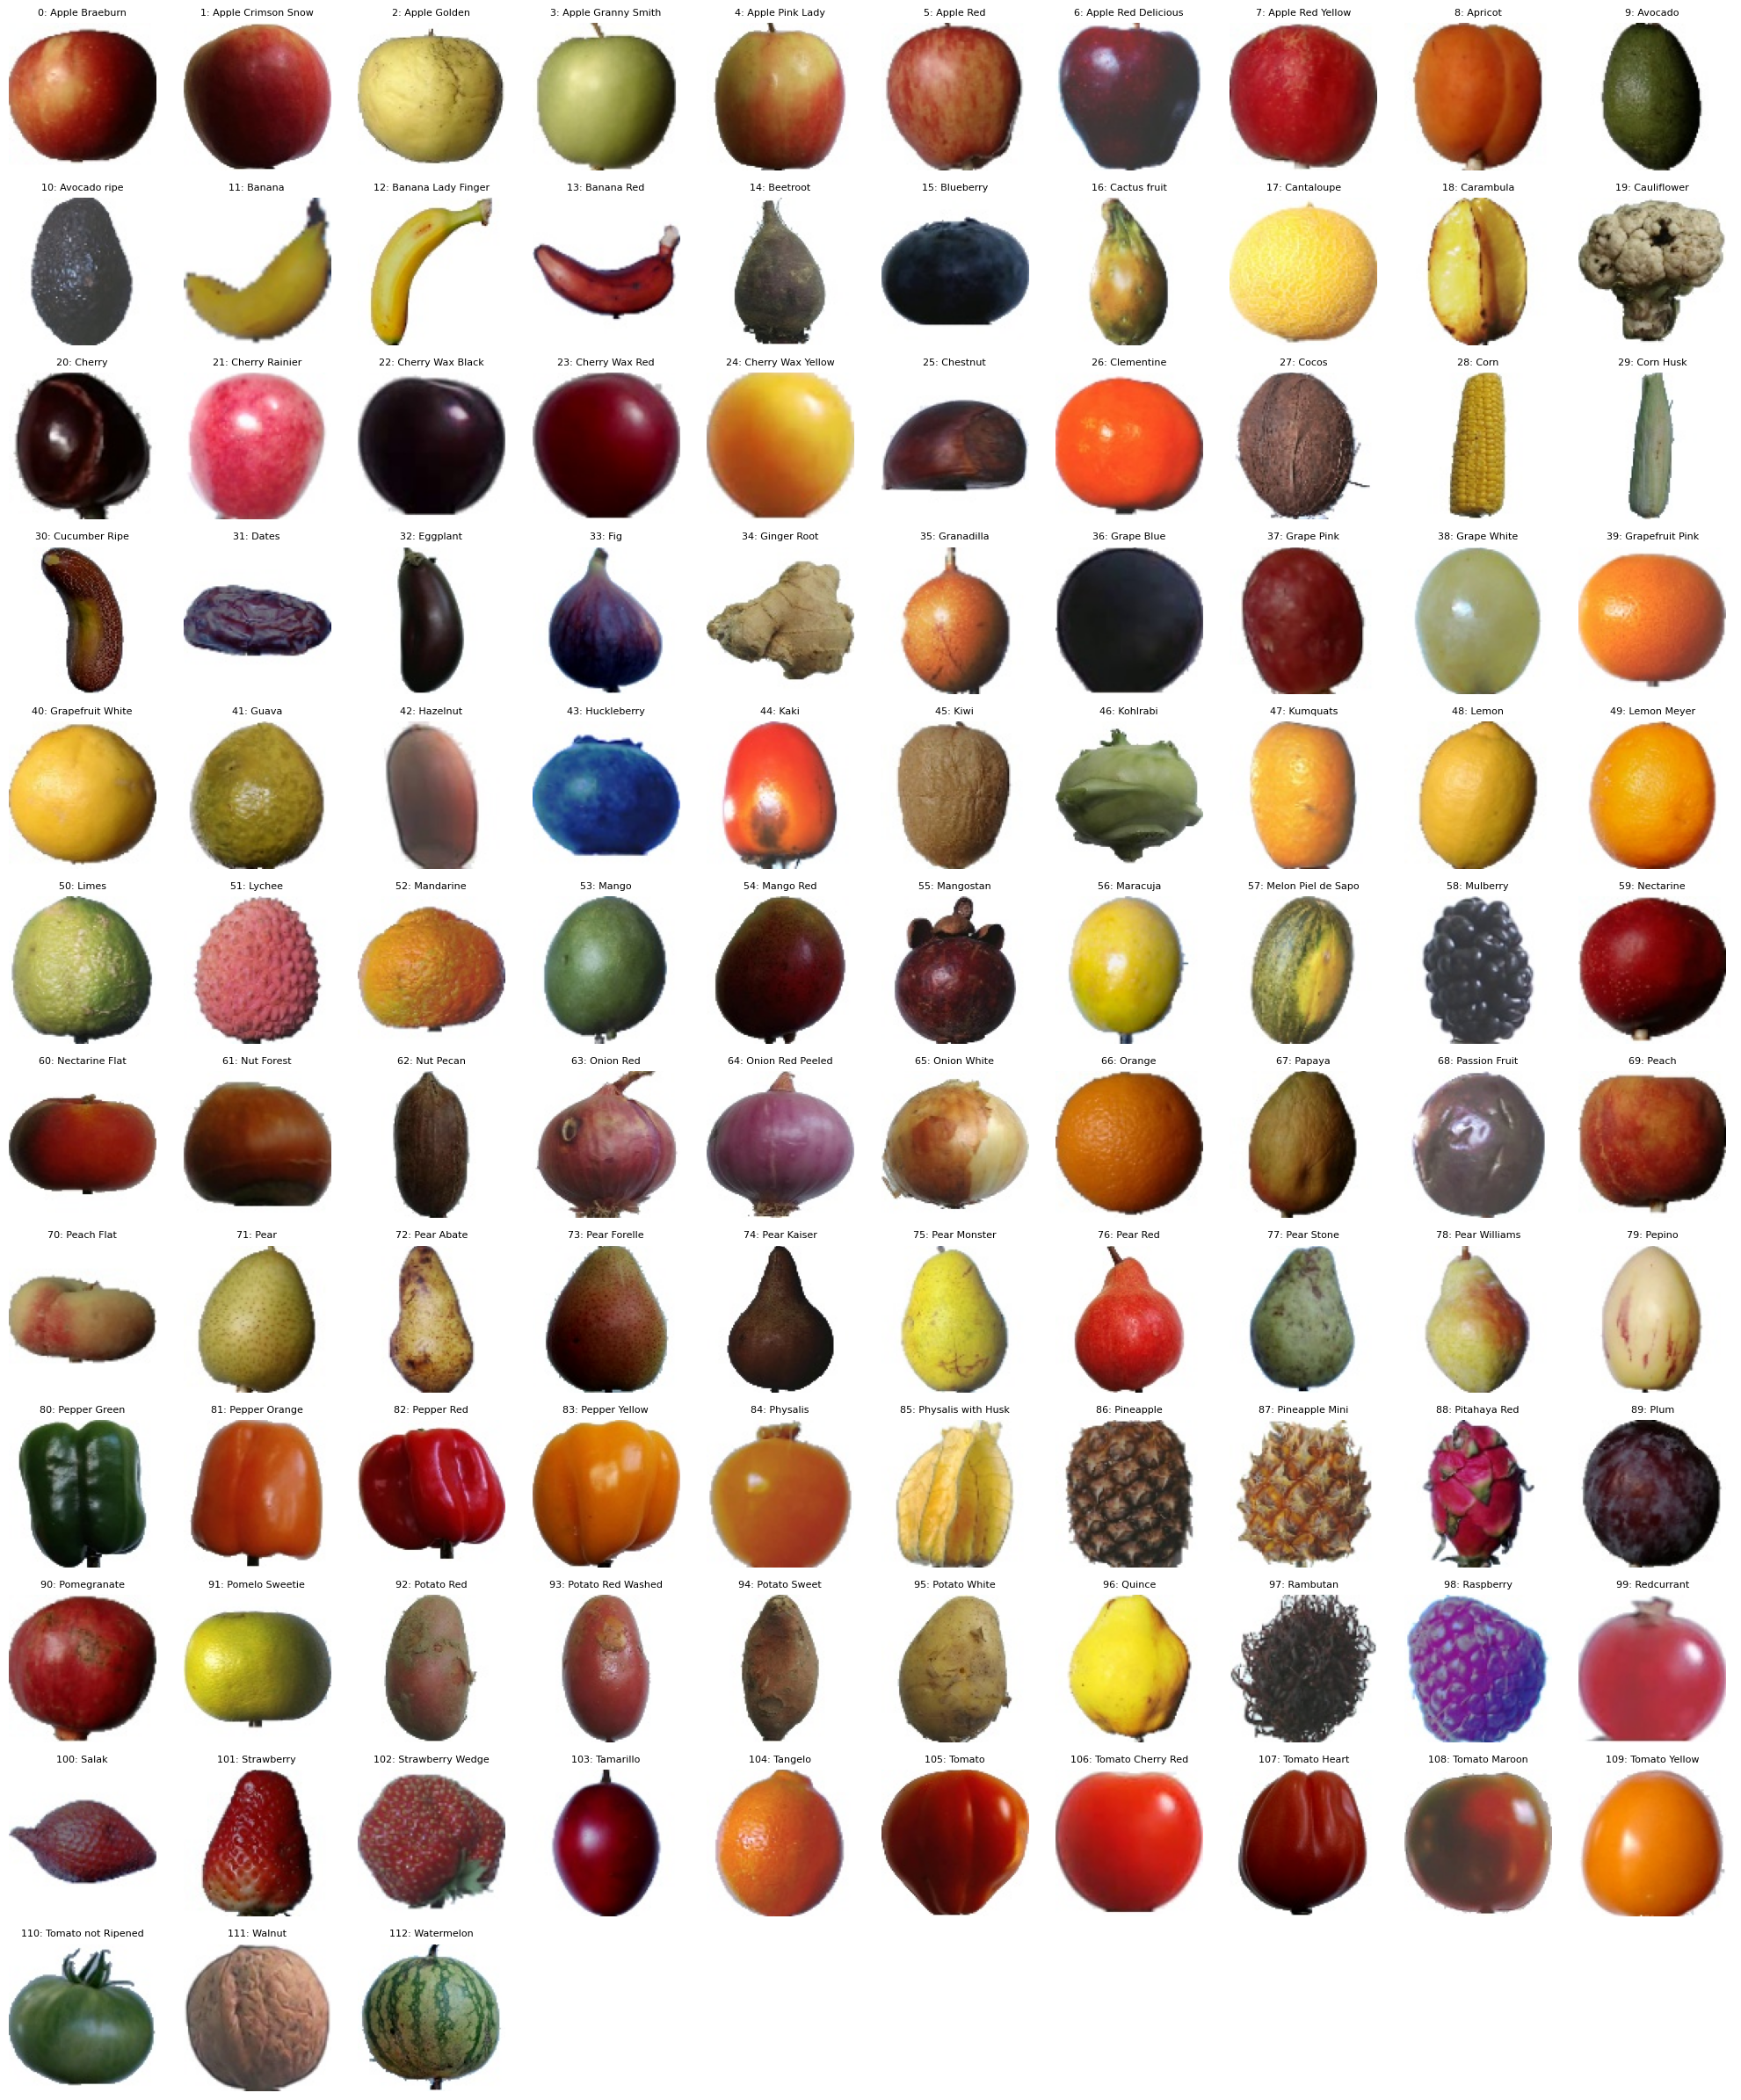

In [4]:
# 샘플 이미지 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 각 클래스별 샘플 1개씩 출력 (전체 클래스 개수가 많으면 일부만)
class_names = ds['train'].features['label'].names
num_classes = len(class_names)

# 전체 클래스 출력 (너무 많으면 줄일 수 있음)
print(f"총 {num_classes}개 클래스:")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")

# 그리드로 샘플 이미지 출력 (전체 클래스)
cols = 10
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows*2))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    # 각 클래스에서 첫 번째 샘플 찾기
    train_data = ds['train']
    sample = train_data.filter(lambda x: x['label'] == i)[0]
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"{i}: {class_name}", fontsize=8)
    axes[i].axis('off')

# 남는 subplot 숨기기
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [6]:
ds.cache_files

{'train': [{'filename': 'C:\\Users\\mbnv6\\.cache\\huggingface\\datasets\\PedroSampaio___fruits-360\\default\\0.0.0\\4aa1175cdbf133ae5d96fcdeeb4d415c07a7f9b2\\fruits-360-train.arrow'}],
 'test': [{'filename': 'C:\\Users\\mbnv6\\.cache\\huggingface\\datasets\\PedroSampaio___fruits-360\\default\\0.0.0\\4aa1175cdbf133ae5d96fcdeeb4d415c07a7f9b2\\fruits-360-test.arrow'}]}

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import Image
import joblib
from tqdm import tqdm

# 데이터셋 확인
print("Dataset splits:", ds.keys())
print("Train size:", len(ds["train"]))
print("Test size:", len(ds["test"]))

Dataset splits: dict_keys(['train', 'test'])
Train size: 67690
Test size: 22688


In [6]:
# 이미지에서 RGB 값 추출 (평균값)
def extract_rgb_from_image(image):
    """PIL Image에서 평균 RGB 값 추출"""
    if isinstance(image, Image.Image):
        img_array = np.array(image.convert("RGB"))
    else:
        img_array = np.array(image)
    
    r = img_array[:,:,0].mean()
    g = img_array[:,:,1].mean()
    b = img_array[:,:,2].mean()
    return r, g, b

# 필터링할 과일 클래스
target_classes = ["Apple Red", "Avocado", "Banana"]
class_names_list = ds["train"].features["label"].names
class_indices = {
    class_names_list.index(name): name 
    for name in target_classes
}
print(f"Target classes: {target_classes}")
print(f"Class indices: {class_indices}\n")

# Fruits-360에서 RGB 데이터 추출 (필터링)
rgb_data = []
labels = []

print("Extracting RGB values from training dataset...")
for item in tqdm(ds["train"]):
    image = item["image"]
    label = item["label"]
    
    if label in class_indices:
        r, g, b = extract_rgb_from_image(image)
        rgb_data.append([r, g, b])
        labels.append(label)

# 테스트셋도 추출 (필터링)
print("Extracting RGB values from test dataset...")
for item in tqdm(ds["test"]):
    image = item["image"]
    label = item["label"]
    
    if label in class_indices:
        r, g, b = extract_rgb_from_image(image)
        rgb_data.append([r, g, b])
        labels.append(label)

X = np.array(rgb_data, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print(f"\nExtracted RGB data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")
print(f"Label distribution: {np.bincount(y)}")

Target classes: ['Apple Red', 'Avocado', 'Banana']
Class indices: {5: 'Apple Red', 9: 'Avocado', 11: 'Banana'}

Extracting RGB values from training dataset...


100%|██████████| 67690/67690 [00:05<00:00, 12368.28it/s]


Extracting RGB values from test dataset...


100%|██████████| 22688/22688 [00:01<00:00, 12593.91it/s]


Extracted RGB data shape: (3110, 3)
Labels shape: (3110,)
Unique labels: [ 5  9 11]
Label distribution: [   0    0    0    0    0 1884    0    0    0  570    0  656]


In [7]:
# 데이터 정제
print("="*50)
print("Data Cleaning")
print("="*50)

# 결측치 확인
df_raw = pd.DataFrame(X, columns=["R", "G", "B"])
df_raw["label"] = y
print(f"Missing values: {df_raw.isnull().sum().sum()}")

# IQR 기반 아웃라이어 제거
Q1 = df_raw[["R","G","B"]].quantile(0.25)
Q3 = df_raw[["R","G","B"]].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df_raw[["R","G","B"]] < (Q1 - 1.5*IQR)) | (df_raw[["R","G","B"]] > (Q3 + 1.5*IQR))).any(axis=1)
df_clean = df_raw[mask].copy()
print(f"Samples removed (outliers): {len(df_raw) - len(df_clean)}")

# 중복 제거
df_clean = df_clean.drop_duplicates(subset=["R","G","B"], keep="first")
print(f"Samples after duplicate removal: {len(df_clean)}")

X = df_clean[["R","G","B"]].values.astype(np.float32)
y = df_clean["label"].values.astype(np.int64)

print(f"Final data shape: {X.shape}")
print(f"Label distribution:\n{pd.Series(y).value_counts().sort_index()}")

Data Cleaning
Missing values: 0
Samples removed (outliers): 739
Samples after duplicate removal: 2371
Final data shape: (2371, 3)
Label distribution:
5     1884
9      405
11      82
Name: count, dtype: int64


In [8]:
# 데이터 전처리
print("="*50)
print("Data Preprocessing")
print("="*50)

# 라벨 인코더
le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(le.classes_)

# 정규화 (0~1)
X = X / 255.0

# 표준화
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Number of classes: {num_classes}")
print(f"Classes: {le.classes_}")
print(f"X shape after preprocessing: {X.shape}")
print(f"X mean: {X.mean(axis=0)}")
print(f"X std: {X.std(axis=0)}")

# 저장 (추론 시 사용)
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le, "label_encoder.joblib")
print("Scaler and LabelEncoder saved!")

Data Preprocessing
Number of classes: 3
Classes: [ 5  9 11]
X shape after preprocessing: (2371, 3)
X mean: [-3.0890843e-07 -3.4752199e-07  1.4158303e-07]
X std: [0.99999994 0.9999999  1.        ]
Scaler and LabelEncoder saved!


In [9]:
# 데이터 분할 (Train/Val/Test = 70/15/15)
print("="*50)
print("Train/Val/Test Split")
print("="*50)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Val labels: {np.bincount(y_val)}")
print(f"Test labels: {np.bincount(y_test)}")

# 데이터로더
train_ds = TensorDataset(
    torch.FloatTensor(X_train), 
    torch.LongTensor(y_train)
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_ds = TensorDataset(
    torch.FloatTensor(X_val), 
    torch.LongTensor(y_val)
)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

test_ds = TensorDataset(
    torch.FloatTensor(X_test),
    torch.LongTensor(y_test)
)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("\nDataLoaders created!")

Train/Val/Test Split
Train: (1659, 3), Val: (356, 3), Test: (356, 3)
Train labels: [1318  283   58]
Val labels: [283  61  12]
Test labels: [283  61  12]

DataLoaders created!


In [10]:
# MLP 모델 정의
class RGBClassifier(nn.Module):
    def __init__(self, input_dim=3, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = RGBClassifier(input_dim=3, num_classes=num_classes)
model.to(device)
print(f"Model created with {num_classes} classes")
print(model)

Using device: cuda
Model created with 3 classes
RGBClassifier(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)


Training
Epoch  20 | Train loss: 0.0005 | Val loss: 0.0001 | Val acc: 1.0000
Epoch  40 | Train loss: 0.0002 | Val loss: 0.0000 | Val acc: 1.0000
Epoch  60 | Train loss: 0.0015 | Val loss: 0.0003 | Val acc: 1.0000
Epoch  80 | Train loss: 0.0001 | Val loss: 0.0001 | Val acc: 1.0000
Epoch 100 | Train loss: 0.0001 | Val loss: 0.0000 | Val acc: 1.0000
Epoch 120 | Train loss: 0.0001 | Val loss: 0.0000 | Val acc: 1.0000
Epoch 140 | Train loss: 0.0002 | Val loss: 0.0000 | Val acc: 1.0000
Epoch 160 | Train loss: 0.0002 | Val loss: 0.0000 | Val acc: 1.0000
Epoch 180 | Train loss: 0.0001 | Val loss: 0.0000 | Val acc: 1.0000
Epoch 200 | Train loss: 0.0002 | Val loss: 0.0000 | Val acc: 1.0000

Best val acc: 1.0000


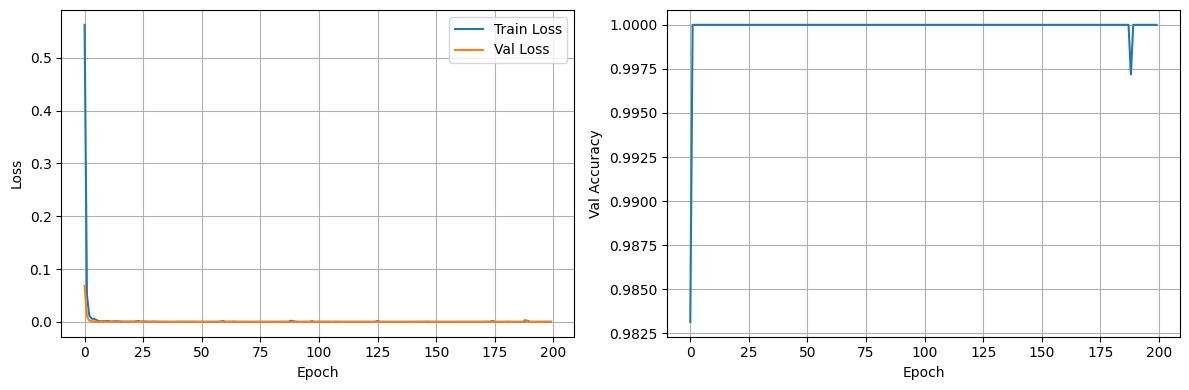

In [11]:
# 학습
print("="*50)
print("Training")
print("="*50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 200
best_val_acc = 0.0
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Val
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()
            pred = logits.argmax(dim=1)
            val_acc += (pred == y_batch).sum().item()
    
    val_acc /= len(X_val)
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    
    # 최고 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "rgb_mlp_best.pth")

print(f"\nBest val acc: {best_val_acc:.4f}")

# 손실/정확도 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(val_accs)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Accuracy")
axes[1].grid()
plt.tight_layout()
plt.show()

Test Evaluation
Test Accuracy: 1.0000
Test F1 (weighted): 1.0000

Confusion Matrix:
[[283   0   0]
 [  0  61   0]
 [  0   0  12]]

Classification Report:
              precision    recall  f1-score   support

   Apple Red       1.00      1.00      1.00       283
     Avocado       1.00      1.00      1.00        61
      Banana       1.00      1.00      1.00        12

    accuracy                           1.00       356
   macro avg       1.00      1.00      1.00       356
weighted avg       1.00      1.00      1.00       356



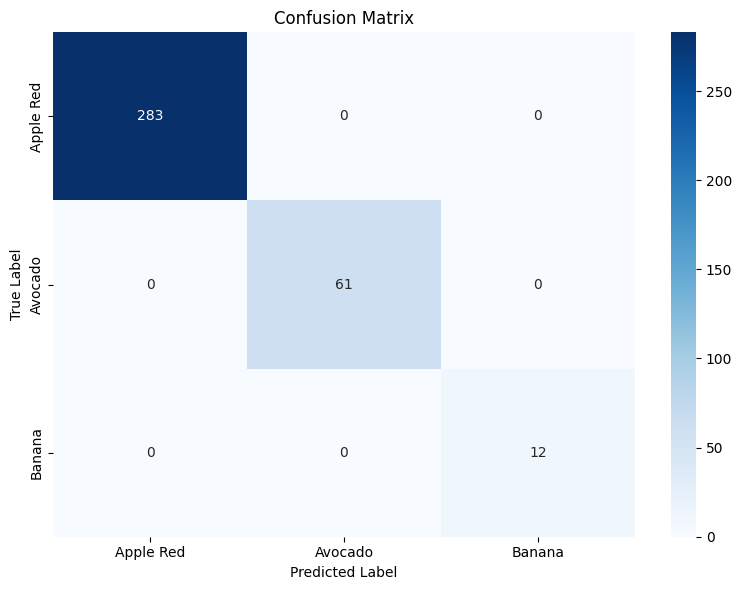

In [12]:
# 테스트 세트 평가
print("="*50)
print("Test Evaluation")
print("="*50)

# 최고 모델 로드
model.load_state_dict(torch.load("rgb_mlp_best.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")
cm = confusion_matrix(all_labels, all_preds)

# 클래스 이름을 문자열로 변환 (원본 과일 이름 사용)
class_names_str = ["Apple Red", "Avocado", "Banana"]

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 (weighted): {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names_str))

# 혼동 행렬 시각화
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_str, yticklabels=class_names_str)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [13]:
# 시리얼 통신 추론 함수 (테스트)
def predict_from_rgb(r, g, b, model, scaler, le, device):
    """RGB 값으로 과일 분류"""
    x = np.array([[r, g, b]], dtype=np.float32) / 255.0
    x = scaler.transform(x)
    
    x_tensor = torch.FloatTensor(x).to(device)
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        prob = probs[0, pred_idx].item()
    
    pred_label = le.classes_[pred_idx]
    return pred_label, prob

# 테스트 샘플들로 시뮬레이션
print("="*50)
print("Simulation with Test Samples")
print("="*50)

model.load_state_dict(torch.load("rgb_mlp_best.pth"))
model.eval()

for i in range(5):
    sample_idx = np.random.randint(0, len(X_test))
    r, g, b = X_test[sample_idx] * np.array(scaler.scale_) + scaler.mean_
    r, g, b = r * 255, g * 255, b * 255  # 원래값으로 역변환
    true_label = le.classes_[y_test[sample_idx]]
    
    pred_label, prob = predict_from_rgb(r, g, b, model, scaler, le, device)
    match = "✓" if pred_label == true_label else "✗"
    print(f"{match} RGB({r:.0f},{g:.0f},{b:.0f}) → Pred: {pred_label} ({prob:.2%}) | True: {true_label}")

Simulation with Test Samples
✓ RGB(154,99,94) → Pred: 5 (100.00%) | True: 5
✓ RGB(177,126,115) → Pred: 5 (99.84%) | True: 5
✓ RGB(150,110,98) → Pred: 5 (99.99%) | True: 5
✓ RGB(169,115,104) → Pred: 5 (99.98%) | True: 5
✓ RGB(200,192,173) → Pred: 11 (86.99%) | True: 11


In [14]:
# 모델 저장 (완전한 형태)
print("="*50)
print("Model Saving")
print("="*50)

import os

# 저장 경로
save_dir = "saved_model"
os.makedirs(save_dir, exist_ok=True)

# 1. 모델 가중치만 저장 (권장)
torch.save(model.state_dict(), f"{save_dir}/rgb_classifier_weights.pth")

# 2. 전체 모델 저장 (모델 구조 + 가중치)
torch.save(model, f"{save_dir}/rgb_classifier_full.pth")

# 3. Scaler, LabelEncoder 복사
import shutil
shutil.copy("scaler.joblib", f"{save_dir}/scaler.joblib")
shutil.copy("label_encoder.joblib", f"{save_dir}/label_encoder.joblib")

# 4. 모델 정보 저장
model_info = {
    "input_dim": 3,
    "num_classes": 3,
    "class_names": ["Apple Red", "Avocado", "Banana"],
    "accuracy": acc,
    "f1_score": f1,
    "architecture": str(model),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
}

import json
with open(f"{save_dir}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"✓ 저장 완료: {save_dir}/")
print(f"  - rgb_classifier_weights.pth (가중치)")
print(f"  - rgb_classifier_full.pth (전체 모델)")
print(f"  - scaler.joblib (스케일러)")
print(f"  - label_encoder.joblib (라벨 인코더)")
print(f"  - model_info.json (모델 정보)")

# 저장된 파일 확인
print(f"\n저장된 파일 목록:")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  {f}: {size:.1f} KB")

Model Saving
✓ 저장 완료: saved_model/
  - rgb_classifier_weights.pth (가중치)
  - rgb_classifier_full.pth (전체 모델)
  - scaler.joblib (스케일러)
  - label_encoder.joblib (라벨 인코더)
  - model_info.json (모델 정보)

저장된 파일 목록:
  label_encoder.joblib: 0.3 KB
  model_info.json: 0.8 KB
  rgb_classifier_full.pth: 48.9 KB
  rgb_classifier_weights.pth: 46.7 KB
  scaler.joblib: 0.6 KB


In [ ]:
# 저장된 모델 로드 테스트 (나중에 사용할 때)
print("="*50)
print("Model Loading Test")
print("="*50)

# 새 모델 인스턴스 생성 후 가중치 로드
loaded_model = RGBClassifier(input_dim=3, num_classes=3)
loaded_model.load_state_dict(torch.load(f"{save_dir}/rgb_classifier_weights.pth"))
loaded_model.to(device)
loaded_model.eval()

# Scaler, LabelEncoder 로드
loaded_scaler = joblib.load(f"{save_dir}/scaler.joblib")
loaded_le = joblib.load(f"{save_dir}/label_encoder.joblib")

# 테스트 추론
test_rgb = [200, 50, 50]  # 빨간색 (Apple Red 예상)
pred_label, prob = predict_from_rgb(*test_rgb, loaded_model, loaded_scaler, loaded_le, device)
print(f"테스트 RGB{test_rgb} → {pred_label} ({prob:.2%})")

test_rgb = [80, 120, 60]  # 초록색 (Avocado 예상)
pred_label, prob = predict_from_rgb(*test_rgb, loaded_model, loaded_scaler, loaded_le, device)
print(f"테스트 RGB{test_rgb} → {pred_label} ({prob:.2%})")

test_rgb = [220, 200, 80]  # 노란색 (Banana 예상)
pred_label, prob = predict_from_rgb(*test_rgb, loaded_model, loaded_scaler, loaded_le, device)
print(f"테스트 RGB{test_rgb} → {pred_label} ({prob:.2%})")

print("\n✓ 모델 로드 및 추론 테스트 완료!")

In [53]:
import serial
import serial.tools.list_ports
import time

# 사용 가능한 시리얼 포트 확인
print("="*50)
print("사용 가능한 시리얼 포트")
print("="*50)

ports = serial.tools.list_ports.comports()
if ports:
    for port in ports:
        print(f"  • {port.device}: {port.description}")
else:
    print("  연결된 포트가 없습니다.")
    print("  아두이노를 USB로 연결해주세요.")

사용 가능한 시리얼 포트
  • COM3: USB-SERIAL CH340(COM3)


In [51]:
# 저장된 모델 로드
print("="*50)
print("모델 로드")
print("="*50)

import json
import joblib
import torch
import numpy as np

save_dir = "saved_model"

# 모델 정보 확인
with open(f"{save_dir}/model_info.json", "r") as f:
    model_info = json.load(f)

print(f"클래스: {model_info['class_names']}")
print(f"학습 정확도: {model_info['accuracy']:.2%}")

# 모델 로드
arduino_model = RGBClassifier(input_dim=3, num_classes=3)
arduino_model.load_state_dict(torch.load(f"{save_dir}/rgb_classifier_weights.pth", weights_only=True))
arduino_model.to(device)
arduino_model.eval()

# Scaler, LabelEncoder 로드
arduino_scaler = joblib.load(f"{save_dir}/scaler.joblib")
arduino_le = joblib.load(f"{save_dir}/label_encoder.joblib")

print("\n모델 로드 완료!")

모델 로드
클래스: ['Apple Red', 'Avocado', 'Banana']
학습 정확도: 100.00%

모델 로드 완료!


In [83]:
# 예측 함수 정의 (실제 센서 데이터 기반 튜닝)
CLASS_NAMES = ["Apple Red", "Avocado", "Banana"]

# ============================================
# 실제 TCS34725 센서 측정값 기반 튜닝 (2026.01.20)
# ============================================
# 🍌 Banana:   R=72-85,  G=111-121, B=48-70,  R-G = -36 ~ -39 (G-R = 36~39)
# 🥑 Avocado:  R=56,     G=122-123, B=74-75,  R-G = -66 ~ -67 (G-R = 66~67)
# 🍎 Apple:    R=140-147, G=56-60,  B=50-54,  R-G = +80 ~ +91
# ============================================

def classify_fruit(r, g, b):
    """
    RGB 값을 받아 과일을 분류합니다.
    실제 TCS34725 센서 측정 데이터 기반 규칙
    
    분류 기준 (G-R 차이 기반):
    - 🥑 Avocado:   G - R >= 55 (진한 초록)
    - 🍌 Banana:    25 <= G - R < 55 (연한 초록/노란색)
    - 🍎 Apple Red: R - G >= 60 (빨간색)
    
    Args:
        r, g, b: RGB 값 (0~255)
    
    Returns:
        tuple: (과일 이름, 신뢰도, 모든 클래스 확률)
    """
    g_r_diff = g - r  # G - R (양수면 초록 계열)
    r_g_diff = r - g  # R - G (양수면 빨간 계열)
    
    # =========================================
    # 실제 센서 데이터 기반 규칙
    # =========================================
    
    # 🥑 Avocado: G - R >= 55 (아보카도는 G가 R보다 55 이상 큼)
    # 실제 측정값: G-R = 66~67
    if g_r_diff >= 55:
        label = "Avocado"
        # G-R 차이가 클수록 높은 신뢰도
        confidence = min(1.0, 0.7 + (g_r_diff - 55) / 30)
        all_probs = {"Apple Red": 0.05, "Avocado": confidence, "Banana": 0.1}
        return label, confidence, all_probs
    
    # 🍌 Banana: 25 <= G - R < 55 (바나나는 G가 R보다 25~55 정도 큼)
    # 실제 측정값: G-R = 36~39
    if 25 <= g_r_diff < 55:
        label = "Banana"
        # G-R이 35~45 범위일수록 높은 신뢰도 (실제 바나나 중심값)
        center = 37.5  # 바나나 중심값
        distance = abs(g_r_diff - center)
        confidence = max(0.7, 1.0 - distance / 20)
        all_probs = {"Apple Red": 0.1, "Avocado": 0.15, "Banana": confidence}
        return label, confidence, all_probs
    
    # 🍎 Apple Red: R - G >= 60 (사과는 R이 G보다 60 이상 큼)
    # 실제 측정값: R-G = 80~91
    if r_g_diff >= 60:
        label = "Apple Red"
        # R-G 차이가 클수록 높은 신뢰도
        confidence = min(1.0, 0.7 + (r_g_diff - 60) / 40)
        all_probs = {"Apple Red": confidence, "Avocado": 0.05, "Banana": 0.1}
        return label, confidence, all_probs
    
    # =========================================
    # 애매한 경우: 모델 사용 또는 추가 규칙
    # =========================================
    
    # G-R이 0~25 범위: 바나나 또는 사과 경계 (노랑-주황 영역)
    if 0 <= g_r_diff < 25:
        # B 값으로 추가 판단 (바나나는 B가 낮음)
        if b < 70:
            label = "Banana"
            confidence = 0.6
        else:
            label = "Apple Red"
            confidence = 0.5
        all_probs = {"Apple Red": 0.4, "Avocado": 0.1, "Banana": 0.5}
        return label, confidence, all_probs
    
    # R-G가 0~60 범위: 사과 또는 바나나 경계
    if 0 < r_g_diff < 60:
        label = "Apple Red"
        confidence = 0.5 + r_g_diff / 120
        all_probs = {"Apple Red": confidence, "Avocado": 0.1, "Banana": 0.4}
        return label, confidence, all_probs
    
    # 그 외: 모델 사용
    x = np.array([[r, g, b]], dtype=np.float32) / 255.0
    x = arduino_scaler.transform(x)
    
    x_tensor = torch.FloatTensor(x).to(device)
    with torch.no_grad():
        logits = arduino_model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    label = CLASS_NAMES[pred_idx]
    all_probs = {CLASS_NAMES[i]: probs[0, i].item() for i in range(3)}
    
    return label, confidence, all_probs

# 함수 테스트 - 실제 센서 데이터로 검증
print("="*70)
print("🔧 튜닝된 분류 함수 테스트 (실제 센서 데이터 기반)")
print("="*70)
print("\n📏 분류 기준:")
print("  🥑 Avocado:   G - R >= 55")
print("  🍌 Banana:    25 <= G - R < 55")
print("  🍎 Apple Red: R - G >= 60")

# 실제 측정된 센서 데이터로 테스트
sensor_data = [
    # 바나나 (1-10번)
    (81, 119, 54, "🍌 Banana #1"),
    (82, 120, 51, "🍌 Banana #2"),
    (84, 121, 48, "🍌 Banana #3"),
    (72, 111, 70, "🍌 Banana #10"),
    # 아보카도 (11-20번)
    (56, 123, 75, "🥑 Avocado #11"),
    (56, 122, 75, "🥑 Avocado #15"),
    (56, 123, 74, "🥑 Avocado #20"),
    # 사과 (22-30번)
    (145, 58, 52, "🍎 Apple #22"),
    (147, 56, 50, "🍎 Apple #27"),
    (140, 60, 54, "🍎 Apple #30"),
    # 아웃라이어 (사과인데 R-G=6)
    (90, 84, 80, "🍎 Apple #21 (outlier)"),
]

print(f"\n{'실제 과일':<22s} | {'RGB':^15s} | {'G-R':>5s} | {'예측':^15s} | {'신뢰도':>8s} | {'결과'}")
print("-"*85)
correct = 0
total = len(sensor_data)
for r, g, b, desc in sensor_data:
    label, conf, probs = classify_fruit(r, g, b)
    emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}.get(label, "❓")
    
    # 정답 확인
    expected = "Banana" if "Banana" in desc else ("Avocado" if "Avocado" in desc else "Apple Red")
    is_correct = label == expected
    if is_correct:
        correct += 1
    result = "✅" if is_correct else "❌"
    
    print(f"{desc:<22s} | ({r:3d},{g:3d},{b:3d}) | {g-r:>5.0f} | {emoji} {label:12s} | {conf:7.1%} | {result}")

print("-"*85)
print(f"정확도: {correct}/{total} = {correct/total*100:.1f}%")

🔧 튜닝된 분류 함수 테스트 (실제 센서 데이터 기반)

📏 분류 기준:
  🥑 Avocado:   G - R >= 55
  🍌 Banana:    25 <= G - R < 55
  🍎 Apple Red: R - G >= 60

실제 과일                  |       RGB       |   G-R |       예측        |      신뢰도 | 결과
-------------------------------------------------------------------------------------
🍌 Banana #1            | ( 81,119, 54) |    38 | 🍌 Banana       |   97.5% | ✅
🍌 Banana #2            | ( 82,120, 51) |    38 | 🍌 Banana       |   97.5% | ✅
🍌 Banana #3            | ( 84,121, 48) |    37 | 🍌 Banana       |   97.5% | ✅
🍌 Banana #10           | ( 72,111, 70) |    39 | 🍌 Banana       |   92.5% | ✅
🥑 Avocado #11          | ( 56,123, 75) |    67 | 🥑 Avocado      |  100.0% | ✅
🥑 Avocado #15          | ( 56,122, 75) |    66 | 🥑 Avocado      |  100.0% | ✅
🥑 Avocado #20          | ( 56,123, 74) |    67 | 🥑 Avocado      |  100.0% | ✅
🍎 Apple #22            | (145, 58, 52) |   -87 | 🍎 Apple Red    |  100.0% | ✅
🍎 Apple #27            | (147, 56, 50) |   -91 | 🍎 Apple Red    |  100.0% | ✅
🍎

In [84]:
# ⚠️ 아두이노 시리얼 통신 설정
# 아래 포트를 실제 아두이노 포트로 변경하세요!

SERIAL_PORT = "COM3"     
BAUD_RATE = 9600        
DURATION = 60             

In [86]:
# 🚀 시리얼 통신 실행 (아두이노 연결 후 실행)
from IPython.display import display, clear_output
import sys

def run_arduino_classification():
    """아두이노에서 RGB 값을 받아 실시간 분류 (엔터 입력 시 1회 측정)"""
    
    try:
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
        print(f"✓ 연결됨: {SERIAL_PORT} @ {BAUD_RATE} baud", flush=True)
        print("="*60, flush=True)
        print("📌 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.")
        print("📌 종료: 'q' 입력 후 엔터", flush=True)
        print("="*60, flush=True)
        
        # 버퍼 비우기
        time.sleep(1)
        ser.reset_input_buffer()
        
        measurement_count = 0
        
        while True:
            # 엔터 입력 대기
            user_input = input("\n[엔터] 측정 시작 (q: 종료) > ").strip().lower()
            
            if user_input == 'q':
                print("\n👋 프로그램 종료", flush=True)
                break
            
            # 버퍼 비우고 새 데이터 대기
            ser.reset_input_buffer()
            print("\n⏳ 측정 중...", flush=True)
            
            # 유효한 RGB 값 1개 수신 대기 (최대 2초)
            start_time = time.time()
            rgb_received = False
            
            while time.time() - start_time < 2.0:
                if ser.in_waiting > 0:
                    try:
                        line = ser.readline().decode('utf-8', errors='ignore').strip()
                        if line:
                            parts = line.split(',')
                            if len(parts) == 3:
                                r, g, b = map(float, parts)
                                if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                    rgb_received = True
                                    
                                    # 분류
                                    label, conf, probs = classify_fruit(r, g, b)
                                    measurement_count += 1
                                    
                                    # 이모지 선택
                                    emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}.get(label, "❓")
                                    
                                    print("\n" + "="*60, flush=True)
                                    print(f"📊 측정 결과 #{measurement_count}", flush=True)
                                    print("-"*60, flush=True)
                                    print(f"  측정 RGB: ({r:.0f}, {g:.0f}, {b:.0f})", flush=True)
                                    print(f"  R - G 차이: {r - g:.0f}", flush=True)
                                    print("-"*60, flush=True)
                                    print(f"  🎯 분류 결과: {emoji} {label}", flush=True)
                                    print(f"  📈 신뢰도: {conf:.1%}", flush=True)
                                    print("-"*60, flush=True)
                                    print("  확률 분포:", flush=True)
                                    for fruit, prob in sorted(probs.items(), key=lambda x: -x[1]):
                                        bar = "█" * int(prob * 20)
                                        e = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}.get(fruit, "")
                                        print(f"    {e} {fruit:12s} {bar} {prob:.1%}", flush=True)
                                    print("="*60, flush=True)
                                    break
                    except:
                        pass
                time.sleep(0.01)
            
            if not rgb_received:
                print("\n⚠️ 데이터를 수신하지 못했습니다.", flush=True)
                print("  - 아두이노가 데이터를 전송하고 있는지 확인하세요.", flush=True)
                print("  - 시리얼 포트가 올바른지 확인하세요.", flush=True)
            
    except serial.SerialException as e:
        print(f"✗ 연결 실패: {e}", flush=True)
        print(f"  위에서 사용 가능한 포트를 확인하고 SERIAL_PORT를 수정하세요.", flush=True)
    except KeyboardInterrupt:
        print("\n\n⚠️ 키보드 인터럽트 - 종료", flush=True)
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print(f"\n✓ 연결 종료 (총 {measurement_count}회 측정)", flush=True)


run_arduino_classification()

✓ 연결됨: COM3 @ 9600 baud
📌 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.
📌 종료: 'q' 입력 후 엔터

⏳ 측정 중...

📊 측정 결과 #1
------------------------------------------------------------
  측정 RGB: (74, 113, 67)
  R - G 차이: -39
------------------------------------------------------------
  🎯 분류 결과: 🍌 Banana
  📈 신뢰도: 92.5%
------------------------------------------------------------
  확률 분포:
    🍌 Banana       ██████████████████ 92.5%
    🥑 Avocado      ███ 15.0%
    🍎 Apple Red    ██ 10.0%

⏳ 측정 중...

📊 측정 결과 #2
------------------------------------------------------------
  측정 RGB: (76, 111, 66)
  R - G 차이: -35
------------------------------------------------------------
  🎯 분류 결과: 🍌 Banana
  📈 신뢰도: 87.5%
------------------------------------------------------------
  확률 분포:
    🍌 Banana       █████████████████ 87.5%
    🥑 Avocado      ███ 15.0%
    🍎 Apple Red    ██ 10.0%

⏳ 측정 중...

📊 측정 결과 #3
------------------------------------------------------------
  측정 RGB: (77, 113, 64)
  R - G 차이: -36
-------------------

In [ ]:
# 🧪 테스트 모드 (아두이노 없이 수동 테스트)
# 아두이노가 없을 때 RGB 값을 직접 입력하여 테스트

def test_manual_input():
    """수동 RGB 입력 테스트"""
    print("="*50)
    print("🧪 수동 테스트 모드")
    print("RGB 값을 입력하세요 (예: 200,50,50)")
    print("종료: 'q' 입력")
    print("="*50)
    
    while True:
        try:
            user_input = input("\nRGB> ").strip()
            
            if user_input.lower() == 'q':
                print("테스트 종료")
                break
            
            r, g, b = map(float, user_input.split(','))
            
            if not (0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255):
                print("⚠ RGB 값은 0~255 범위입니다")
                continue
            
            label, conf, probs = classify_fruit(r, g, b)
            emoji = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}.get(label, "❓")
            
            print(f"\n  결과: {emoji} {label} (신뢰도: {conf:.1%})")
            print(f"  확률 분포:")
            for fruit, prob in probs.items():
                bar = "█" * int(prob * 20)
                e = {"Apple Red": "🍎", "Avocado": "🥑", "Banana": "🍌"}.get(fruit, "")
                print(f"    {e} {fruit:12s} {bar} {prob:.1%}")
                
        except ValueError:
            print("⚠ 형식 오류! 예시: 200,50,50")
        except KeyboardInterrupt:
            print("\n테스트 종료")
            break

# 테스트 실행 (아래 주석 해제)
# test_manual_input()

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_25492\539484913.py:33: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s

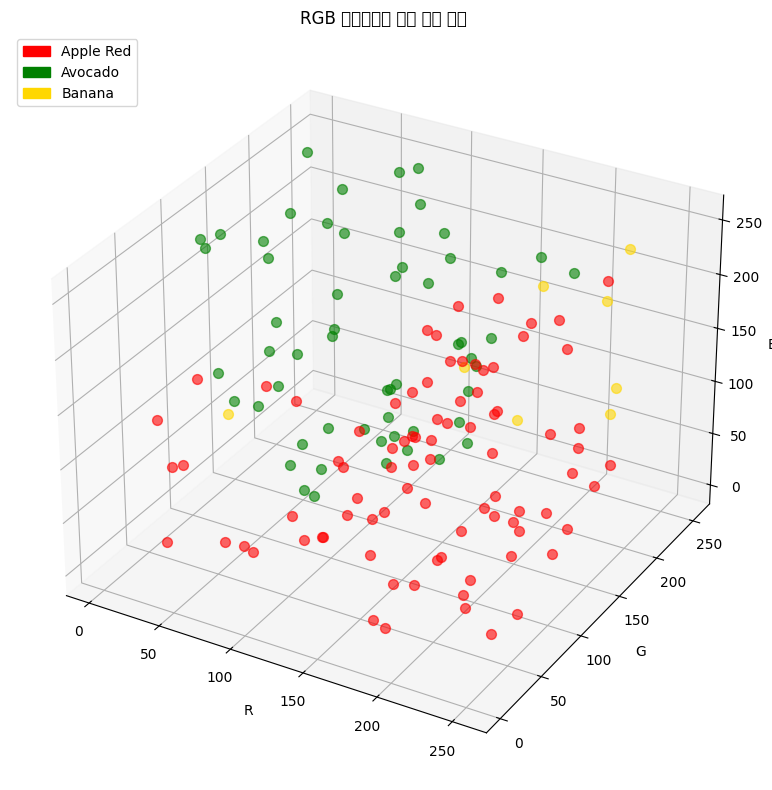

총 150개 샘플 시각화 (신뢰도 70% 이상)


In [87]:
# 📊 RGB 공간 시각화 (모델 예측 영역)
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# RGB 샘플 생성 및 예측
samples = []
for _ in range(200):
    r, g, b = np.random.randint(0, 256, 3)
    label, conf, _ = classify_fruit(r, g, b)
    if conf > 0.7:  # 신뢰도 70% 이상만
        samples.append({'r': r, 'g': g, 'b': b, 'label': label, 'conf': conf})

# 3D 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'Apple Red': 'red', 'Avocado': 'green', 'Banana': 'gold'}
for s in samples:
    ax.scatter(s['r'], s['g'], s['b'], 
               c=colors.get(s['label'], 'gray'),
               s=50, alpha=0.6)

ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
ax.set_title('RGB 공간에서의 과일 분류 영역')

# 범례
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=f"{l}") for l, c in colors.items()]
ax.legend(handles=patches, loc='upper left')

plt.tight_layout()
plt.show()

print(f"총 {len(samples)}개 샘플 시각화 (신뢰도 70% 이상)")

In [88]:
# 임계값을 계속 추가하다보니 규칙기반 분류가 되어버림;;